# Tutorial 14_B — English to Urdu Translation using RNN

## Objective

This notebook implements **Tutorial 14_B: English to Urdu Translation Using an RNN** using PyTorch.

The tutorial covers:

- Preparing a small English–Urdu sentence-pair dataset
- Tokenizing English and Urdu sentences
- Creating vocabularies
- Building an encoder-decoder RNN model
- Training the model for sequence-to-sequence translation
- Generating translations for new English sentences
- Changing hidden units, epochs, and learning rate
- Developing a one-to-many RNN model for baby name generation

The main tasks are:

1. Make your own dataset and test it with the model
2. Change the number of units, epochs, and learning rate
3. Develop a one-to-many RNN model for baby name generation


## 1. Import Required Libraries

In [1]:
import os
import re
import sys
import time
import random
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# Optional libraries for correct Urdu / Arabic text rendering in matplotlib images.
# If installation is not possible, the notebook will still run,
# but Urdu table images may not render perfectly.
try:
    import arabic_reshaper
    from bidi.algorithm import get_display
    RTL_SUPPORT = True
except ImportError:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "arabic-reshaper", "python-bidi"])
        import arabic_reshaper
        from bidi.algorithm import get_display
        RTL_SUPPORT = True
    except Exception as e:
        print("Optional RTL packages could not be installed.")
        print("Urdu text may display incorrectly in saved matplotlib table images.")
        print("Reason:", e)
        RTL_SUPPORT = False

def fix_urdu_text(text):
    # Fix Urdu / Arabic right-to-left text for matplotlib table images.
    # The original DataFrame is kept unchanged for normal notebook display.
    if not isinstance(text, str):
        return text

    if RTL_SUPPORT:
        reshaped_text = arabic_reshaper.reshape(text)
        bidi_text = get_display(reshaped_text)
        return bidi_text

    return text

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("RTL support for Urdu table images:", RTL_SUPPORT)

os.makedirs("images", exist_ok=True)


PyTorch version: 2.5.1+cu121
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
RTL support for Urdu table images: True


## 2. Prepare English–Urdu Dataset

The tutorial requires an English–Urdu dataset.  
A small custom sentence-pair dataset is created inside the notebook.

Each pair contains:

- English sentence
- Corresponding Urdu sentence

This is a sequence-to-sequence problem:

English sentence → Encoder RNN → Decoder RNN → Urdu sentence


In [2]:
sentence_pairs = [
    ("hello", "سلام"),
    ("how are you", "آپ کیسے ہیں"),
    ("i am fine", "میں ٹھیک ہوں"),
    ("what is your name", "آپ کا نام کیا ہے"),
    ("my name is ali", "میرا نام علی ہے"),
    ("i love pakistan", "مجھے پاکستان سے محبت ہے"),
    ("where are you going", "آپ کہاں جا رہے ہیں"),
    ("i am going home", "میں گھر جا رہا ہوں"),
    ("this is my book", "یہ میری کتاب ہے"),
    ("the weather is good", "موسم اچھا ہے"),
    ("i like tea", "مجھے چائے پسند ہے"),
    ("he is my friend", "وہ میرا دوست ہے"),
    ("she is a teacher", "وہ ایک استاد ہے"),
    ("open the door", "دروازہ کھولو"),
    ("close the window", "کھڑکی بند کرو"),
    ("thank you", "شکریہ"),
    ("good morning", "صبح بخیر"),
    ("good night", "شب بخیر"),
    ("i am a student", "میں ایک طالب علم ہوں"),
    ("we are learning", "ہم سیکھ رہے ہیں"),
    ("this is easy", "یہ آسان ہے"),
    ("that is difficult", "وہ مشکل ہے"),
    ("i live in islamabad", "میں اسلام آباد میں رہتا ہوں"),
    ("lahore is a city", "لاہور ایک شہر ہے"),
    ("i study deep learning", "میں ڈیپ لرننگ پڑھتا ہوں"),
    ("the cat is small", "بلی چھوٹی ہے"),
    ("the dog is big", "کتا بڑا ہے"),
    ("bring some water", "کچھ پانی لاؤ"),
    ("i need help", "مجھے مدد چاہیے"),
    ("see you tomorrow", "کل ملاقات ہوگی")
]

print("Number of sentence pairs:", len(sentence_pairs))

for english, urdu in sentence_pairs[:5]:
    print(f"{english}  ->  {urdu}")


Number of sentence pairs: 30
hello  ->  سلام
how are you  ->  آپ کیسے ہیں
i am fine  ->  میں ٹھیک ہوں
what is your name  ->  آپ کا نام کیا ہے
my name is ali  ->  میرا نام علی ہے


## 3. Tokenization and Vocabulary Creation

Special tokens are used:

- `<PAD>` for padding
- `<SOS>` for start of sentence
- `<EOS>` for end of sentence
- `<UNK>` for unknown words

English is tokenized by spaces.  
Urdu is also tokenized by spaces for this small demonstration.


In [3]:
PAD_TOKEN = "<PAD>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
UNK_TOKEN = "<UNK>"

def tokenize_english(sentence):
    sentence = sentence.lower().strip()
    sentence = re.sub(r"[^a-zA-Z ]", "", sentence)
    return sentence.split()

def tokenize_urdu(sentence):
    return sentence.strip().split()

english_tokenized = [tokenize_english(pair[0]) for pair in sentence_pairs]
urdu_tokenized = [tokenize_urdu(pair[1]) for pair in sentence_pairs]

def build_vocab(tokenized_sentences):
    vocab = {
        PAD_TOKEN: 0,
        SOS_TOKEN: 1,
        EOS_TOKEN: 2,
        UNK_TOKEN: 3
    }

    for sentence in tokenized_sentences:
        for token in sentence:
            if token not in vocab:
                vocab[token] = len(vocab)

    return vocab

english_vocab = build_vocab(english_tokenized)
urdu_vocab = build_vocab(urdu_tokenized)

idx_to_english = {idx: token for token, idx in english_vocab.items()}
idx_to_urdu = {idx: token for token, idx in urdu_vocab.items()}

print("English vocabulary size:", len(english_vocab))
print("Urdu vocabulary size:", len(urdu_vocab))

print("\nEnglish vocab sample:")
print(list(english_vocab.items())[:10])

print("\nUrdu vocab sample:")
print(list(urdu_vocab.items())[:10])


English vocabulary size: 65
Urdu vocabulary size: 72

English vocab sample:
[('<PAD>', 0), ('<SOS>', 1), ('<EOS>', 2), ('<UNK>', 3), ('hello', 4), ('how', 5), ('are', 6), ('you', 7), ('i', 8), ('am', 9)]

Urdu vocab sample:
[('<PAD>', 0), ('<SOS>', 1), ('<EOS>', 2), ('<UNK>', 3), ('سلام', 4), ('آپ', 5), ('کیسے', 6), ('ہیں', 7), ('میں', 8), ('ٹھیک', 9)]


## 4. Encode and Pad Sentences

In [4]:
max_encoder_len = max(len(tokens) for tokens in english_tokenized) + 2
max_decoder_len = max(len(tokens) for tokens in urdu_tokenized) + 2

def encode_tokens(tokens, vocab, max_len):
    encoded = [vocab[SOS_TOKEN]]
    encoded += [vocab.get(token, vocab[UNK_TOKEN]) for token in tokens]
    encoded += [vocab[EOS_TOKEN]]

    if len(encoded) < max_len:
        encoded += [vocab[PAD_TOKEN]] * (max_len - len(encoded))

    return encoded[:max_len]

encoder_inputs = np.array(
    [encode_tokens(tokens, english_vocab, max_encoder_len) for tokens in english_tokenized],
    dtype=np.int64
)

decoder_sequences = np.array(
    [encode_tokens(tokens, urdu_vocab, max_decoder_len) for tokens in urdu_tokenized],
    dtype=np.int64
)

# Decoder input excludes the last token
decoder_inputs = decoder_sequences[:, :-1]

# Decoder target excludes the first token
decoder_targets = decoder_sequences[:, 1:]

print("Encoder input shape:", encoder_inputs.shape)
print("Decoder input shape:", decoder_inputs.shape)
print("Decoder target shape:", decoder_targets.shape)
print("Max encoder length:", max_encoder_len)
print("Max decoder length:", max_decoder_len)


Encoder input shape: (30, 6)
Decoder input shape: (30, 7)
Decoder target shape: (30, 7)
Max encoder length: 6
Max decoder length: 8


## 5. Train/Test Split and DataLoader

In [5]:
indices = np.arange(len(sentence_pairs))
np.random.seed(SEED)
np.random.shuffle(indices)

split_index = int(0.8 * len(indices))

train_indices = indices[:split_index]
test_indices = indices[split_index:]

X_encoder_train = encoder_inputs[train_indices]
X_decoder_train = decoder_inputs[train_indices]
y_train = decoder_targets[train_indices]

X_encoder_test = encoder_inputs[test_indices]
X_decoder_test = decoder_inputs[test_indices]
y_test = decoder_targets[test_indices]

print("Training pairs:", len(train_indices))
print("Testing pairs:", len(test_indices))


Training pairs: 24
Testing pairs: 6


In [6]:
class TranslationDataset(Dataset):
    def __init__(self, encoder_inputs, decoder_inputs, decoder_targets):
        self.encoder_inputs = torch.tensor(encoder_inputs, dtype=torch.long)
        self.decoder_inputs = torch.tensor(decoder_inputs, dtype=torch.long)
        self.decoder_targets = torch.tensor(decoder_targets, dtype=torch.long)

    def __len__(self):
        return len(self.encoder_inputs)

    def __getitem__(self, idx):
        return self.encoder_inputs[idx], self.decoder_inputs[idx], self.decoder_targets[idx]


train_dataset = TranslationDataset(X_encoder_train, X_decoder_train, y_train)
test_dataset = TranslationDataset(X_encoder_test, X_decoder_test, y_test)

batch_size = 4

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


## 6. Build Encoder-Decoder RNN Model

The model contains:

- Encoder: reads the English sentence and returns the final hidden state.
- Decoder: uses that hidden state and predicts Urdu words.


In [7]:
class EncoderRNN(nn.Module):
    def __init__(self, input_vocab_size, embedding_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(
            input_vocab_size,
            embedding_dim,
            padding_idx=english_vocab[PAD_TOKEN]
        )

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

    def forward(self, encoder_input):
        embedded = self.embedding(encoder_input)
        outputs, hidden = self.rnn(embedded)
        return hidden


class DecoderRNN(nn.Module):
    def __init__(self, output_vocab_size, embedding_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(
            output_vocab_size,
            embedding_dim,
            padding_idx=urdu_vocab[PAD_TOKEN]
        )

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, output_vocab_size)

    def forward(self, decoder_input, hidden):
        embedded = self.embedding(decoder_input)
        outputs, hidden = self.rnn(embedded, hidden)
        logits = self.fc(outputs)
        return logits, hidden


class Seq2SeqRNN(nn.Module):
    def __init__(self, input_vocab_size, output_vocab_size, embedding_dim=64, hidden_dim=128):
        super().__init__()

        self.encoder = EncoderRNN(input_vocab_size, embedding_dim, hidden_dim)
        self.decoder = DecoderRNN(output_vocab_size, embedding_dim, hidden_dim)

    def forward(self, encoder_input, decoder_input):
        hidden = self.encoder(encoder_input)
        logits, hidden = self.decoder(decoder_input, hidden)
        return logits


baseline_model = Seq2SeqRNN(
    input_vocab_size=len(english_vocab),
    output_vocab_size=len(urdu_vocab),
    embedding_dim=64,
    hidden_dim=128
).to(device)

print(baseline_model)


Seq2SeqRNN(
  (encoder): EncoderRNN(
    (embedding): Embedding(65, 64, padding_idx=0)
    (rnn): RNN(64, 128, batch_first=True)
  )
  (decoder): DecoderRNN(
    (embedding): Embedding(72, 64, padding_idx=0)
    (rnn): RNN(64, 128, batch_first=True)
    (fc): Linear(in_features=128, out_features=72, bias=True)
  )
)


## 7. Training, Evaluation, and Plotting Functions

In [8]:
def sequence_accuracy(logits, targets):
    predictions = torch.argmax(logits, dim=-1)
    mask = targets != urdu_vocab[PAD_TOKEN]

    correct = ((predictions == targets) & mask).sum().item()
    total = mask.sum().item()

    if total == 0:
        return 0.0

    return correct / total


def train_translation_model(model, train_loader, test_loader, epochs=80, learning_rate=0.001):
    criterion = nn.CrossEntropyLoss(ignore_index=urdu_vocab[PAD_TOKEN])
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "test_loss": [],
        "train_accuracy": [],
        "test_accuracy": []
    }

    start_time = time.time()

    for epoch in range(epochs):
        model.train()

        train_loss = 0.0
        train_acc = 0.0
        train_batches = 0

        for enc_input, dec_input, target in train_loader:
            enc_input = enc_input.to(device)
            dec_input = dec_input.to(device)
            target = target.to(device)

            logits = model(enc_input, dec_input)

            loss = criterion(
                logits.reshape(-1, logits.shape[-1]),
                target.reshape(-1)
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_acc += sequence_accuracy(logits, target)
            train_batches += 1

        train_loss /= train_batches
        train_acc /= train_batches

        model.eval()

        test_loss = 0.0
        test_acc = 0.0
        test_batches = 0

        with torch.no_grad():
            for enc_input, dec_input, target in test_loader:
                enc_input = enc_input.to(device)
                dec_input = dec_input.to(device)
                target = target.to(device)

                logits = model(enc_input, dec_input)

                loss = criterion(
                    logits.reshape(-1, logits.shape[-1]),
                    target.reshape(-1)
                )

                test_loss += loss.item()
                test_acc += sequence_accuracy(logits, target)
                test_batches += 1

        test_loss /= test_batches
        test_acc /= test_batches

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_accuracy"].append(train_acc)
        history["test_accuracy"].append(test_acc)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(
                f"Epoch {epoch + 1}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Test Loss: {test_loss:.4f} | "
                f"Train Acc: {train_acc * 100:.2f}% | "
                f"Test Acc: {test_acc * 100:.2f}%"
            )

    total_time = time.time() - start_time

    return history, total_time


def plot_history(history, title, filename):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_accuracy"], label="Train Accuracy")
    plt.plot(epochs_range, history["test_accuracy"], label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Token Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["test_loss"], label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def save_dataframe_as_image(df, filename, title=None, fontsize=9):
    fig_width = max(8, len(df.columns) * 3.0)
    fig_height = max(2.5, len(df) * 0.55 + 1.2)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.5)

    if title:
        ax.set_title(title, fontsize=12, pad=12)

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


## 8. Train the Baseline Translation Model

In [9]:
torch.manual_seed(SEED)

baseline_model = Seq2SeqRNN(
    input_vocab_size=len(english_vocab),
    output_vocab_size=len(urdu_vocab),
    embedding_dim=64,
    hidden_dim=128
).to(device)

baseline_history, baseline_time = train_translation_model(
    baseline_model,
    train_loader,
    test_loader,
    epochs=80,
    learning_rate=0.001
)

print("Baseline training time:", round(baseline_time, 2), "seconds")
print("Trainable parameters:", count_trainable_parameters(baseline_model))


Epoch 1/80 | Train Loss: 4.2617 | Test Loss: 4.2078 | Train Acc: 1.76% | Test Acc: 7.89%
Epoch 20/80 | Train Loss: 0.4943 | Test Loss: 4.0363 | Train Acc: 95.20% | Test Acc: 29.43%
Epoch 40/80 | Train Loss: 0.0952 | Test Loss: 4.3752 | Train Acc: 100.00% | Test Acc: 32.06%
Epoch 60/80 | Train Loss: 0.0367 | Test Loss: 4.6145 | Train Acc: 100.00% | Test Acc: 32.06%
Epoch 80/80 | Train Loss: 0.0199 | Test Loss: 4.7752 | Train Acc: 100.00% | Test Acc: 32.06%
Baseline training time: 2.59 seconds
Trainable parameters: 67720


## 9. Plot Baseline Training Curves

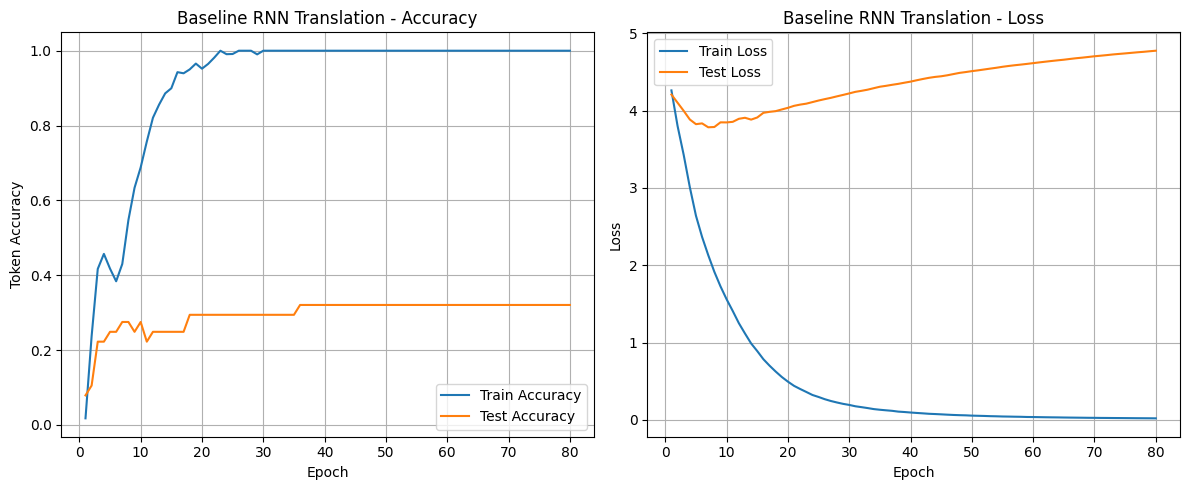

In [10]:
plot_history(
    baseline_history,
    "Baseline RNN Translation",
    "images/tutorial_14B_baseline_training_curves.png"
)


## 10. Generate Translations

The model generates Urdu tokens one by one.

Generation starts with `<SOS>` and stops when `<EOS>` is predicted or the maximum length is reached.


In [11]:
def encode_english_sentence(sentence):
    tokens = tokenize_english(sentence)
    encoded = [english_vocab[SOS_TOKEN]]
    encoded += [english_vocab.get(token, english_vocab[UNK_TOKEN]) for token in tokens]
    encoded += [english_vocab[EOS_TOKEN]]

    if len(encoded) < max_encoder_len:
        encoded += [english_vocab[PAD_TOKEN]] * (max_encoder_len - len(encoded))

    return encoded[:max_encoder_len]


def translate_sentence(model, sentence, max_length=None):
    if max_length is None:
        max_length = max_decoder_len

    model.eval()

    encoded_sentence = encode_english_sentence(sentence)
    encoder_input = torch.tensor([encoded_sentence], dtype=torch.long).to(device)

    with torch.no_grad():
        hidden = model.encoder(encoder_input)

        decoder_input = torch.tensor([[urdu_vocab[SOS_TOKEN]]], dtype=torch.long).to(device)

        output_tokens = []

        for _ in range(max_length):
            logits, hidden = model.decoder(decoder_input, hidden)
            predicted_idx = torch.argmax(logits[:, -1, :], dim=-1).item()

            if predicted_idx == urdu_vocab[EOS_TOKEN]:
                break

            if predicted_idx not in [urdu_vocab[PAD_TOKEN], urdu_vocab[SOS_TOKEN]]:
                output_tokens.append(idx_to_urdu[predicted_idx])

            decoder_input = torch.tensor([[predicted_idx]], dtype=torch.long).to(device)

    return " ".join(output_tokens)


test_sentences = [
    "how are you",
    "i like tea",
    "i need help",
    "good morning",
    "i live in islamabad"
]

translation_results = []

for sentence in test_sentences:
    translation = translate_sentence(baseline_model, sentence)
    translation_results.append((sentence, translation))
    print(f"{sentence:25s} -> {translation}")


how are you               -> آپ کیسے ہیں
i like tea                -> مجھے پاکستان سے محبت ہے
i need help               -> مجھے مدد چاہیے
good morning              -> صبح بخیر
i live in islamabad       -> میں اسلام آباد میں رہتا ہوں


## 11. Save Baseline Translation Results

The original DataFrame keeps normal Urdu text.

For the saved matplotlib image only, Urdu text is reshaped and converted using bidi formatting so it appears correctly in the image.


,English Sentence,Predicted Urdu Translation
0,how are you,آپ کیسے ہیں
1,i like tea,مجھے پاکستان سے محبت ہے
2,i need help,مجھے مدد چاہیے
3,good morning,صبح بخیر
4,i live in islamabad,میں اسلام آباد میں رہتا ہوں


C:\Users\mumer\AppData\Local\Temp\ipykernel_3916\916675266.py:155: UserWarning: Glyph 64424 (\N{ARABIC LETTER HEH GOAL INITIAL FORM}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, dpi=300, bbox_inches="tight")
C:\Users\mumer\AppData\Local\Temp\ipykernel_3916\916675266.py:155: UserWarning: Glyph 64431 (\N{ARABIC LETTER YEH BARREE FINAL FORM}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, dpi=300, bbox_inches="tight")
C:\Users\mumer\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 64424 (\N{ARABIC LETTER HEH GOAL INITIAL FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\mumer\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 64431 (\N{ARABIC LETTER YEH BARREE FINAL FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


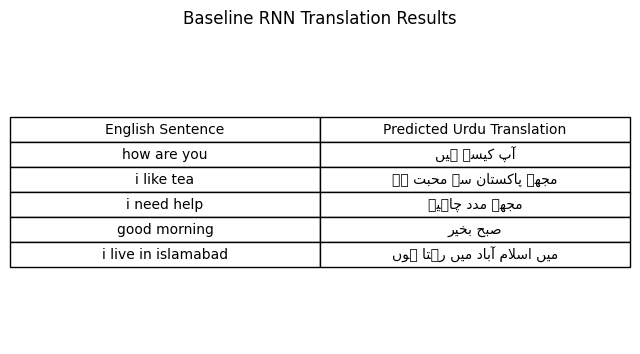

In [12]:
translation_df = pd.DataFrame(
    translation_results,
    columns=["English Sentence", "Predicted Urdu Translation"]
)

# Keep original DataFrame for notebook display
display(translation_df)

# Use a fixed copy only for saving the image table
translation_df_image = translation_df.copy()
translation_df_image["Predicted Urdu Translation"] = translation_df_image["Predicted Urdu Translation"].apply(fix_urdu_text)

save_dataframe_as_image(
    translation_df_image,
    "images/tutorial_14B_baseline_translation_table.png",
    title="Baseline RNN Translation Results",
    fontsize=10
)


# Task — Change Units, Epochs, and Learning Rate

The tutorial task asks to change:

- Number of hidden units
- Number of epochs
- Learning rate

Several configurations are tested and compared.


In [13]:
experiment_configs = [
    {
        "Name": "Small_RNN",
        "Hidden Units": 64,
        "Epochs": 60,
        "Learning Rate": 0.001
    },
    {
        "Name": "Baseline_RNN",
        "Hidden Units": 128,
        "Epochs": 80,
        "Learning Rate": 0.001
    },
    {
        "Name": "Large_RNN",
        "Hidden Units": 256,
        "Epochs": 80,
        "Learning Rate": 0.001
    },
    {
        "Name": "High_LR",
        "Hidden Units": 128,
        "Epochs": 80,
        "Learning Rate": 0.01
    },
    {
        "Name": "Low_LR",
        "Hidden Units": 128,
        "Epochs": 80,
        "Learning Rate": 0.0005
    }
]

experiment_results = []
experiment_histories = {}
experiment_models = {}

for config in experiment_configs:
    print("\nTraining:", config["Name"])

    torch.manual_seed(SEED)

    model = Seq2SeqRNN(
        input_vocab_size=len(english_vocab),
        output_vocab_size=len(urdu_vocab),
        embedding_dim=64,
        hidden_dim=config["Hidden Units"]
    ).to(device)

    history, training_time = train_translation_model(
        model,
        train_loader,
        test_loader,
        epochs=config["Epochs"],
        learning_rate=config["Learning Rate"]
    )

    experiment_results.append({
        "Model": config["Name"],
        "Hidden Units": config["Hidden Units"],
        "Epochs": config["Epochs"],
        "Learning Rate": config["Learning Rate"],
        "Final Train Acc": history["train_accuracy"][-1],
        "Final Test Acc": history["test_accuracy"][-1],
        "Final Train Loss": history["train_loss"][-1],
        "Final Test Loss": history["test_loss"][-1],
        "Training Time (s)": training_time,
        "Trainable Parameters": count_trainable_parameters(model)
    })

    experiment_histories[config["Name"]] = history
    experiment_models[config["Name"]] = model

experiment_results_df = pd.DataFrame(experiment_results)
experiment_results_df



Training: Small_RNN
Epoch 1/60 | Train Loss: 4.3016 | Test Loss: 4.3468 | Train Acc: 1.88% | Test Acc: 5.26%
Epoch 20/60 | Train Loss: 1.4078 | Test Loss: 3.8514 | Train Acc: 76.03% | Test Acc: 30.14%
Epoch 40/60 | Train Loss: 0.5104 | Test Loss: 4.0445 | Train Acc: 95.26% | Test Acc: 32.06%
Epoch 60/60 | Train Loss: 0.2343 | Test Loss: 4.2469 | Train Acc: 97.46% | Test Acc: 32.06%

Training: Baseline_RNN
Epoch 1/80 | Train Loss: 4.2617 | Test Loss: 4.2078 | Train Acc: 1.76% | Test Acc: 7.89%
Epoch 20/80 | Train Loss: 0.4943 | Test Loss: 4.0363 | Train Acc: 95.20% | Test Acc: 29.43%
Epoch 40/80 | Train Loss: 0.0952 | Test Loss: 4.3752 | Train Acc: 100.00% | Test Acc: 32.06%
Epoch 60/80 | Train Loss: 0.0367 | Test Loss: 4.6145 | Train Acc: 100.00% | Test Acc: 32.06%
Epoch 80/80 | Train Loss: 0.0199 | Test Loss: 4.7752 | Train Acc: 100.00% | Test Acc: 32.06%

Training: Large_RNN
Epoch 1/80 | Train Loss: 4.2432 | Test Loss: 4.1096 | Train Acc: 8.71% | Test Acc: 10.53%
Epoch 20/80 | Train

,Model,Hidden Units,Epochs,Learning Rate,Final Train Acc,Final Test Acc,Final Train Loss,Final Test Loss,Training Time (s),Trainable Parameters
0,Small_RNN,64,60,0.0010,0.974561,0.320574,0.234292,4.246936,2.058939,30088
1,Baseline_RNN,128,80,0.0010,1.000000,0.320574,0.019855,4.775155,3.102286,67720
2,Large_RNN,256,80,0.0010,1.000000,0.275120,0.005456,5.217722,2.913664,192136
3,High_LR,128,80,0.0100,1.000000,0.294258,0.001286,7.160592,2.629678,67720
4,Low_LR,128,80,0.0005,1.000000,0.320574,0.086511,4.368218,2.548766,67720


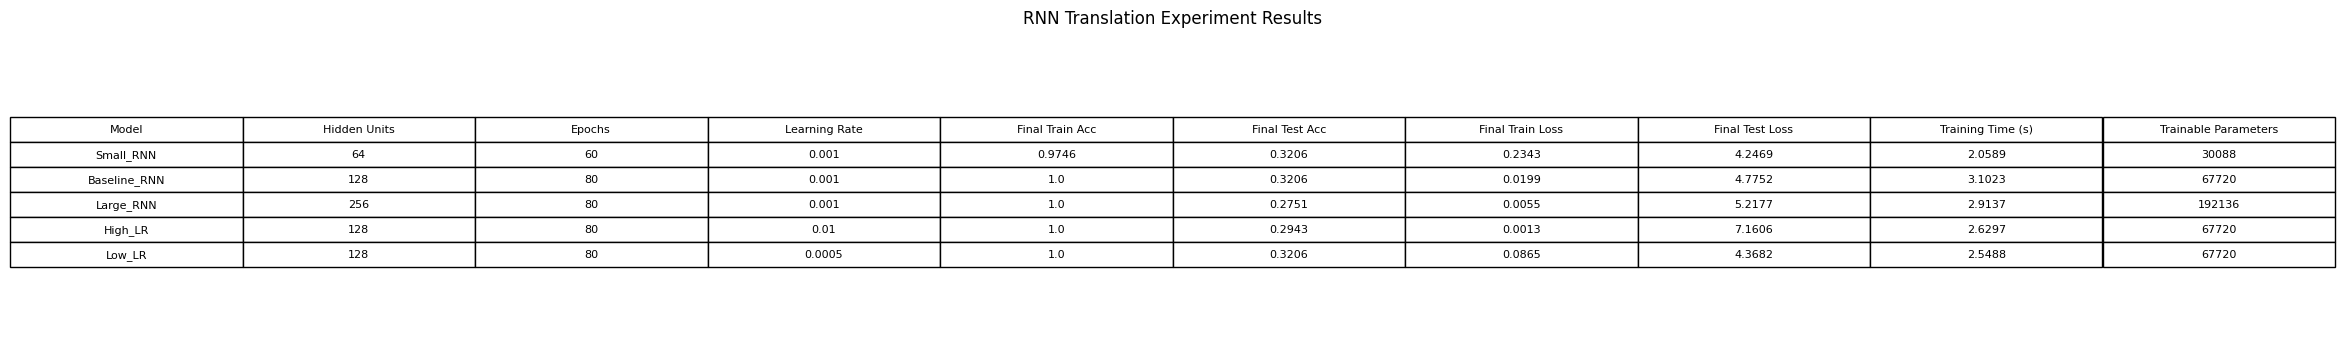

In [14]:
experiment_image_df = experiment_results_df.copy()

for column in ["Final Train Acc", "Final Test Acc", "Final Train Loss", "Final Test Loss", "Training Time (s)"]:
    experiment_image_df[column] = experiment_image_df[column].round(4)

save_dataframe_as_image(
    experiment_image_df,
    "images/tutorial_14B_experiment_results_table.png",
    title="RNN Translation Experiment Results",
    fontsize=8
)


## 12. Compare Experiment Curves

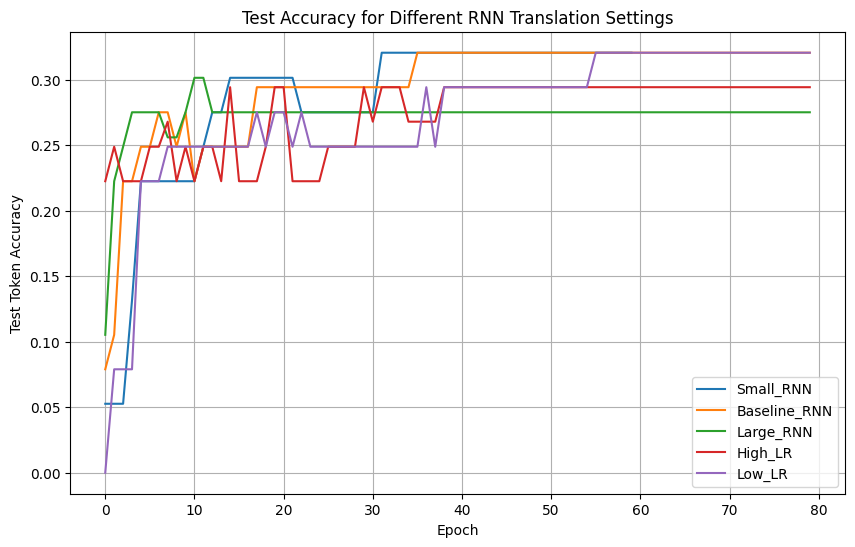

In [15]:
plt.figure(figsize=(10, 6))

for model_name, history in experiment_histories.items():
    plt.plot(history["test_accuracy"], label=model_name)

plt.xlabel("Epoch")
plt.ylabel("Test Token Accuracy")
plt.title("Test Accuracy for Different RNN Translation Settings")
plt.legend()
plt.grid(True)
plt.savefig("images/tutorial_14B_experiment_accuracy_curves.png", dpi=300, bbox_inches="tight")
plt.show()


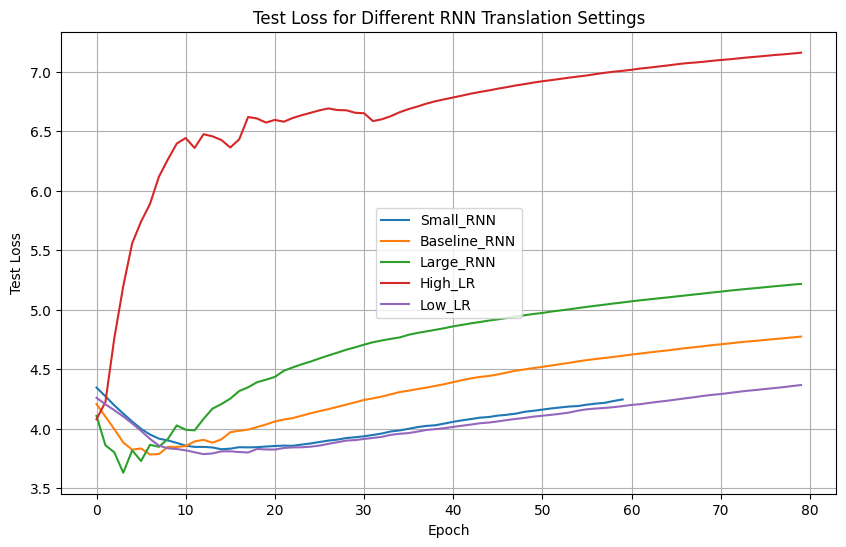

In [16]:
plt.figure(figsize=(10, 6))

for model_name, history in experiment_histories.items():
    plt.plot(history["test_loss"], label=model_name)

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Test Loss for Different RNN Translation Settings")
plt.legend()
plt.grid(True)
plt.savefig("images/tutorial_14B_experiment_loss_curves.png", dpi=300, bbox_inches="tight")
plt.show()


## 13. Best Model Translation Results

Best model: Small_RNN
Model                   Small_RNN
Hidden Units                   64
Epochs                         60
Learning Rate               0.001
Final Train Acc          0.974561
Final Test Acc           0.320574
Final Train Loss         0.234292
Final Test Loss          4.246936
Training Time (s)        2.058939
Trainable Parameters        30088
Name: 0, dtype: object
how are you               -> آپ کیسے ہیں
i like tea                -> مجھے مدد چاہیے
i need help               -> مجھے مدد چاہیے
good morning              -> صبح بخیر
i live in islamabad       -> میں ایک طالب علم ہوں


,English Sentence,Best Model Urdu Translation
0,how are you,آپ کیسے ہیں
1,i like tea,مجھے مدد چاہیے
2,i need help,مجھے مدد چاہیے
3,good morning,صبح بخیر
4,i live in islamabad,میں ایک طالب علم ہوں


C:\Users\mumer\AppData\Local\Temp\ipykernel_3916\916675266.py:155: UserWarning: Glyph 64424 (\N{ARABIC LETTER HEH GOAL INITIAL FORM}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, dpi=300, bbox_inches="tight")
C:\Users\mumer\AppData\Local\Temp\ipykernel_3916\916675266.py:155: UserWarning: Glyph 64431 (\N{ARABIC LETTER YEH BARREE FINAL FORM}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, dpi=300, bbox_inches="tight")
C:\Users\mumer\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 64424 (\N{ARABIC LETTER HEH GOAL INITIAL FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\mumer\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 64431 (\N{ARABIC LETTER YEH BARREE FINAL FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


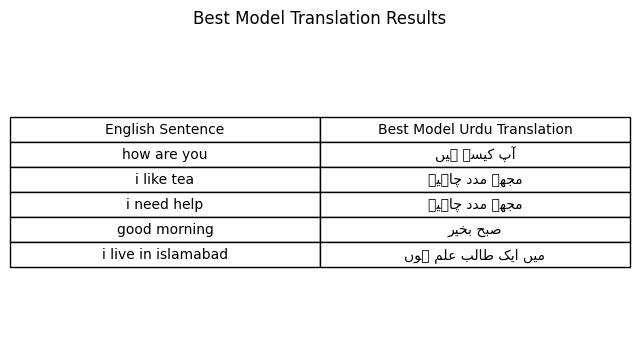

In [17]:
best_row = experiment_results_df.sort_values(by="Final Test Acc", ascending=False).iloc[0]

best_model_name = best_row["Model"]
best_model = experiment_models[best_model_name]

print("Best model:", best_model_name)
print(best_row)

best_translation_results = []

for sentence in test_sentences:
    translation = translate_sentence(best_model, sentence)
    best_translation_results.append((sentence, translation))
    print(f"{sentence:25s} -> {translation}")

best_translation_df = pd.DataFrame(
    best_translation_results,
    columns=["English Sentence", "Best Model Urdu Translation"]
)

# Keep original DataFrame for notebook display
display(best_translation_df)

# Use a fixed copy only for saving the image table
best_translation_df_image = best_translation_df.copy()
best_translation_df_image["Best Model Urdu Translation"] = best_translation_df_image["Best Model Urdu Translation"].apply(fix_urdu_text)

save_dataframe_as_image(
    best_translation_df_image,
    "images/tutorial_14B_best_model_translation_table.png",
    title="Best Model Translation Results",
    fontsize=10
)


# Task — One-to-Many RNN for Baby Name Generation

A one-to-many RNN receives one starting token/character and generates a sequence.

Here, a character-level RNN is trained on a small list of baby names.

The model learns character patterns and generates new names one character at a time.


In [18]:
baby_names = [
    "Aarav", "Ayaan", "Ali", "Ahmed", "Hassan", "Hamza", "Zayan", "Rayyan",
    "Omar", "Usman", "Bilal", "Danish", "Fahad", "Saad", "Taimoor",
    "Ayesha", "Fatima", "Maryam", "Zainab", "Hania", "Sara", "Noor",
    "Maha", "Laiba", "Iqra", "Amna", "Sana", "Eshal", "Zoya", "Areeba"
]

baby_names = [name.lower() for name in baby_names]

chars = sorted(set("".join(baby_names)))
char_to_idx = {PAD_TOKEN: 0, SOS_TOKEN: 1, EOS_TOKEN: 2}

for ch in chars:
    char_to_idx[ch] = len(char_to_idx)

idx_to_char = {idx: ch for ch, idx in char_to_idx.items()}

max_name_len = max(len(name) for name in baby_names) + 2

def encode_name(name):
    encoded = [char_to_idx[SOS_TOKEN]]
    encoded += [char_to_idx[ch] for ch in name]
    encoded += [char_to_idx[EOS_TOKEN]]

    if len(encoded) < max_name_len:
        encoded += [char_to_idx[PAD_TOKEN]] * (max_name_len - len(encoded))

    return encoded[:max_name_len]

name_sequences = np.array([encode_name(name) for name in baby_names], dtype=np.int64)

name_inputs = name_sequences[:, :-1]
name_targets = name_sequences[:, 1:]

print("Number of baby names:", len(baby_names))
print("Character vocabulary size:", len(char_to_idx))
print("Name input shape:", name_inputs.shape)
print("Name target shape:", name_targets.shape)


Number of baby names: 30
Character vocabulary size: 22
Name input shape: (30, 8)
Name target shape: (30, 8)


In [19]:
class NameDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = torch.tensor(inputs, dtype=torch.long)
        self.targets = torch.tensor(targets, dtype=torch.long)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]


name_dataset = NameDataset(name_inputs, name_targets)
name_loader = DataLoader(name_dataset, batch_size=4, shuffle=True)


In [20]:
class NameGeneratorRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=32, hidden_dim=128):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=char_to_idx[PAD_TOKEN])

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        embedded = self.embedding(x)
        outputs, hidden = self.rnn(embedded, hidden)
        logits = self.fc(outputs)
        return logits, hidden


name_model = NameGeneratorRNN(
    vocab_size=len(char_to_idx),
    embedding_dim=32,
    hidden_dim=128
).to(device)

print(name_model)


NameGeneratorRNN(
  (embedding): Embedding(22, 32, padding_idx=0)
  (rnn): RNN(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=22, bias=True)
)


In [21]:
def train_name_generator(model, data_loader, epochs=200, learning_rate=0.005):
    criterion = nn.CrossEntropyLoss(ignore_index=char_to_idx[PAD_TOKEN])
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "loss": []
    }

    for epoch in range(epochs):
        model.train()

        total_loss = 0.0
        batches = 0

        for inputs, targets in data_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            logits, hidden = model(inputs)

            loss = criterion(
                logits.reshape(-1, logits.shape[-1]),
                targets.reshape(-1)
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            batches += 1

        avg_loss = total_loss / batches
        history["loss"].append(avg_loss)

        if (epoch + 1) % 50 == 0 or epoch == 0:
            print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f}")

    return history


torch.manual_seed(SEED)

name_model = NameGeneratorRNN(
    vocab_size=len(char_to_idx),
    embedding_dim=32,
    hidden_dim=128
).to(device)

name_history = train_name_generator(
    name_model,
    name_loader,
    epochs=200,
    learning_rate=0.005
)


Epoch 1/200 | Loss: 2.6738
Epoch 50/200 | Loss: 0.6383
Epoch 100/200 | Loss: 0.6201
Epoch 150/200 | Loss: 0.6130
Epoch 200/200 | Loss: 0.6165


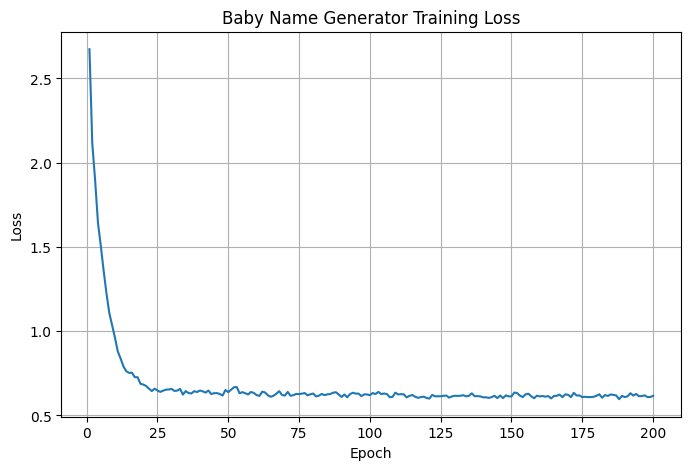

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(name_history["loss"]) + 1), name_history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baby Name Generator Training Loss")
plt.grid(True)
plt.savefig("images/tutorial_14B_name_generator_loss.png", dpi=300, bbox_inches="tight")
plt.show()


Generated baby names:
Areeba
Hamza
Saad
Zoya
Mfa
Reetamed
Iqra
Hassan
Laiba
Zayan


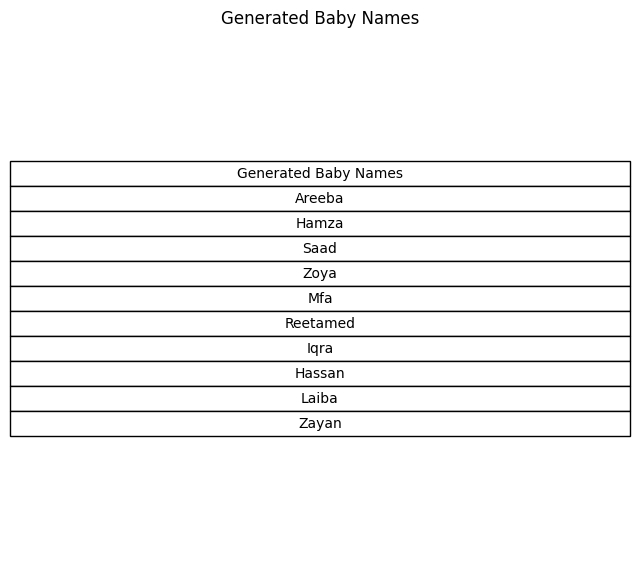

,Generated Baby Names
0,Areeba
1,Hamza
2,Saad
3,Zoya
4,Mfa
5,Reetamed
6,Iqra
7,Hassan
8,Laiba
9,Zayan


In [23]:
def generate_name(model, start_char=None, max_length=12, temperature=0.8):
    model.eval()

    if start_char is None:
        input_idx = char_to_idx[SOS_TOKEN]
        generated = ""
    else:
        start_char = start_char.lower()
        input_idx = char_to_idx.get(start_char, char_to_idx[SOS_TOKEN])
        generated = start_char if start_char in char_to_idx else ""

    input_tensor = torch.tensor([[input_idx]], dtype=torch.long).to(device)
    hidden = None

    with torch.no_grad():
        for _ in range(max_length):
            logits, hidden = model(input_tensor, hidden)
            logits = logits[:, -1, :] / temperature

            probabilities = torch.softmax(logits, dim=-1)
            predicted_idx = torch.multinomial(probabilities, num_samples=1).item()

            if predicted_idx == char_to_idx[EOS_TOKEN]:
                break

            if predicted_idx not in [char_to_idx[PAD_TOKEN], char_to_idx[SOS_TOKEN]]:
                generated += idx_to_char[predicted_idx]

            input_tensor = torch.tensor([[predicted_idx]], dtype=torch.long).to(device)

    return generated.capitalize()


generated_names = []

for start_char in ["a", "h", "s", "z", "m", "r", None, None, None, None]:
    generated_names.append(generate_name(name_model, start_char=start_char))

print("Generated baby names:")
for name in generated_names:
    print(name)

generated_names_df = pd.DataFrame({"Generated Baby Names": generated_names})

save_dataframe_as_image(
    generated_names_df,
    "images/tutorial_14B_generated_names_table.png",
    title="Generated Baby Names",
    fontsize=10
)

generated_names_df


# Final Observations

## RNN Translation

The encoder-decoder RNN learned to map English token sequences to Urdu token sequences using a small custom dataset.

## Urdu Display Note

Urdu is a right-to-left language.  
For normal notebook output, the original Urdu strings are kept unchanged.  
For saved matplotlib table images, Urdu text is reshaped and converted for better right-to-left display.

## Experiment Results

Different hidden units, epochs, and learning rates were tested.

The model can memorize small sentence pairs, but real translation requires much larger parallel text datasets.

## Baby Name Generator

The one-to-many RNN generated character sequences after learning patterns from a small baby-name dataset.

## Key Learning

RNNs are useful for sequential tasks such as translation and text generation.  
For translation, the input and output are both sequences.  
For name generation, one starting input can produce a full output sequence.
